# Notebook for plotting evaluation metrics for drone swarm

Structure of the drone_data:

[# neighbors, avg neighbors dist, dist to center, viewing error, viewing coverage]

## First test: Outter vs Convex Hull viewing metric
Keeping neighbors metric to topological, # drones to 10

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
# Read data dict
FILEPATH = "output/2D_outter2_topological_{0}.npy"
NB_TESTS = 8
from_ = 2
to = 9
data = []
timing_data = []
try:
    for i in range(from_, to+1):
        data.append(np.load(FILEPATH.format(2), allow_pickle=True).item())
except FileNotFoundError:
    print('File not found')

all_drone_data = np.array([d['drone_data'] for d in data])
timings = np.array([d['timings'] for d in data])
swarm_centers = np.array([d['swarm_center'] for d in data])

(8, 17508) (8, 17508)


C:\Users\alexa\AppData\Local\Temp\ipykernel_47120\1380615012.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('jet')


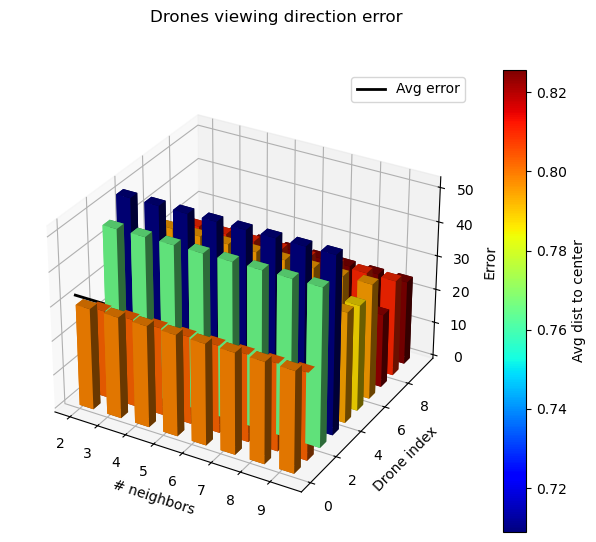

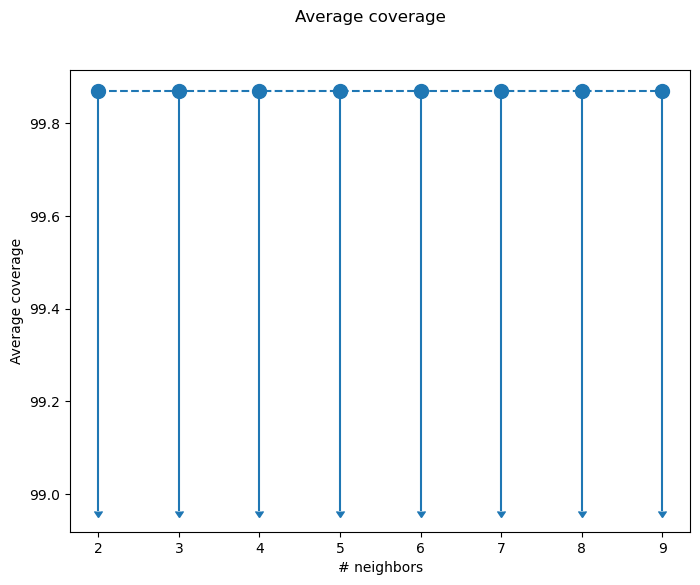

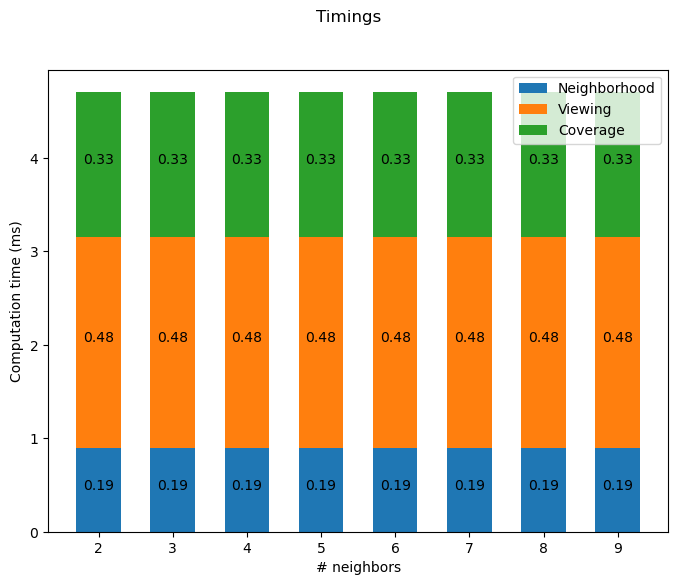

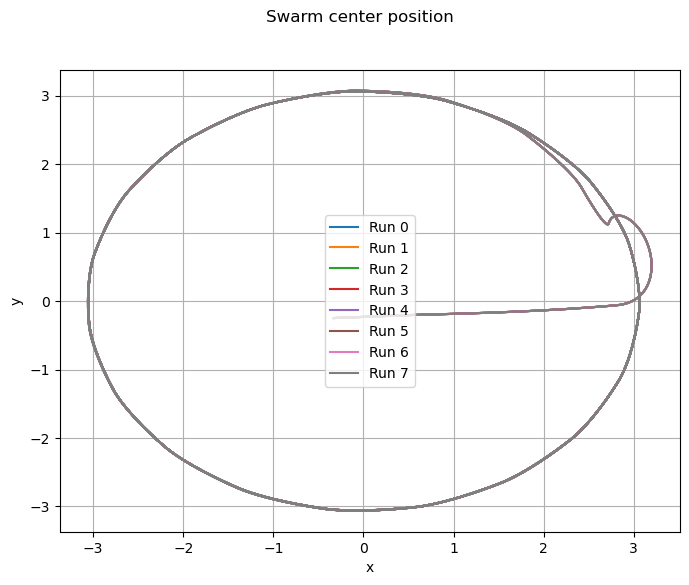

In [153]:
# 1- Plot the drone viewing direction error
fig = plt.figure(figsize=(8, 6))
fig.suptitle('Drones viewing direction error')
ax = fig.add_subplot(1, 1, 1, projection='3d')
# Labelling
ax.set_xlabel('# neighbors')
ax.set_ylabel('Drone index')
ax.set_zlabel('Error')
# Create the bins
nb_drones = data[0]['params']['drone_count']
xpos, ypos = np.meshgrid(np.arange(from_, to+1), np.arange(nb_drones))
xpos = xpos.flatten('F')
ypos = ypos.flatten('F')
zpos = np.zeros_like(xpos)
# Find the average error for each drone
errors = np.mean(all_drone_data[:, :, :, 3], axis=1)

# Construct arrays with the dimensions for the bars.
dx = 0.5 * np.ones_like(xpos)
dy = 0.5 * np.ones_like(ypos)
dz = errors.T.flatten('F')

# Create color map with dist to center (on average)
colormap = cm.get_cmap('jet')
dist_to_center = np.mean(np.abs(all_drone_data[:, :, :, 2]), axis=1)
max_height = np.max(dist_to_center)
min_height = np.min(dist_to_center)
dist_to_center = dist_to_center.T.flatten('F')
colors = colormap((dist_to_center - min_height) / (max_height-min_height))
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, zsort='average')
ax.set_box_aspect(aspect=None, zoom=0.95)
cbar = plt.colorbar(cm.ScalarMappable(Normalize(vmin=min_height, vmax=max_height), cmap=colormap), ax=ax, orientation='vertical')
cbar.set_label('Avg dist to center')

# Add average over all drones as 2d line
avg_errors = np.mean(errors, axis=1)
ax.plot(np.arange(from_, to+1), avg_errors, zs=0, zdir='y', color='black', label='Avg error', linewidth=2)
ax.legend()

# 2- Plot the average coverage
fig2 = plt.figure(figsize=(8, 6))
fig2.suptitle('Average coverage')
ax2 = fig2.add_subplot(1, 1, 1)
ax2.set_xlabel('# neighbors')
ax2.set_ylabel('Average coverage')
# Find the average coverage for each drone
coverage_mean = np.mean(all_drone_data[:, :, :, 4], axis=(1,2))
coverage_std = np.std(all_drone_data[:, :, :, 4], axis=(1,2))
ax2.errorbar(np.arange(from_, to+1), coverage_mean*100, yerr=coverage_std*100, fmt='o--', label='Coverage', uplims=100, markersize=10)

# 3- Plot the different timings
fig3 = plt.figure(figsize=(8, 6))
fig3.suptitle('Timings')
ax3 = fig3.add_subplot(1, 1, 1)
ax3.set_xlabel('# neighbors')
ax3.set_ylabel('Computation time (ms)')
# Compute average timings
timings_neighborhood = np.mean(timings[:, :, 0], axis=1)*1000
timings_viewing = np.mean(timings[:, :, 1], axis=1)*1000
timings_coverage = np.mean(timings[:, :, 2], axis=1)*1000
timings_total = timings_neighborhood + timings_viewing + timings_coverage

x_values = np.arange(from_, to+1)
ax3.bar(x_values, timings_neighborhood, width=0.6, label='Neighborhood')
ax3.bar(x_values, timings_viewing, width=0.6, label='Viewing', bottom=timings_neighborhood)
ax3.bar(x_values, timings_coverage, width=0.6, label='Coverage', bottom=timings_neighborhood+timings_viewing)
for i in range(to-from_+1):
    value = round(timings_neighborhood[i]/timings_total[i] ,2)
    ax3.text(x_values[i], timings_neighborhood[i]/2, value, ha = 'center')
    value = round(timings_viewing[i]/timings_total[i] ,2)
    ax3.text(x_values[i], timings_neighborhood[i]+timings_viewing[i]/2, value, ha = 'center')
    value = round(timings_coverage[i]/timings_total[i] ,2)
    ax3.text(x_values[i], timings_neighborhood[i]+timings_viewing[i]+timings_coverage[i]/2, value, ha = 'center')
ax3.legend()

# Plot the swarm center position over time
fig4 = plt.figure(figsize=(8, 6))
fig4.suptitle('Swarm center position')
ax4 = fig4.add_subplot(1, 1, 1)
ax4.set_xlabel('x')
ax4.set_ylabel('y')
# Compute center x,y
center_x = swarm_centers[:, :, 0]
center_y = swarm_centers[:, :, 1]
print(center_x.shape, center_y.shape)
for i in range(center_x.shape[0]):
    ax4.plot(center_x[i, :], center_y[i, :], label=f'Run {i}')
# ax4.plot(center_x, center_y, 'b-', linewidth=2)
ax4.grid(True)
ax4.legend()